In [ ]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm.auto import tqdm

# 1. Carica il nuovo file
df = pd.read_csv('news_per_sentiment_split.csv')

# 2. Setup Modello
device = 0 if torch.cuda.is_available() else -1
sentiment_task = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device)

# 3. Analisi (usiamo la colonna 'testo_per_ai' che contiene il summary)
batch_size = 32
scores = []

print(f"Analisi in corso su {len(df)} news finanziarie...")

for i in tqdm(range(0, len(df), batch_size)):
    batch_texts = df['testo_per_ai'].iloc[i:i+batch_size].astype(str).tolist()
    # FinBERT restituisce Label (Pos/Neg/Neut) e Score (Confidenza)
    results = sentiment_task(batch_texts, truncation=True, max_length=512)

    # Trasformiamo in punteggio numerico unico tra -1 e 1
    for res in results:
        s = res['score']
        if res['label'] == 'negative':
            scores.append(-s)
        elif res['label'] == 'positive':
            scores.append(s)
        else:
            scores.append(0) # Neutrale

# 4. Salvataggio
df['sentiment_score'] = scores
df.to_csv('news_con_sentiment_split_finale1.csv', index=False)
print("\nAnalisi completata! Scarica il file 'news_con_sentiment_split_finale.csv'.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Analisi in corso su 7692 news finanziarie...


  0%|          | 0/241 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Analisi completata! Scarica il file 'news_con_sentiment_split_finale.csv'.


In [2]:
import pandas as pd
import numpy as np
import random
import os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler # Aggiunto ParameterSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# --- 0. SET SEED PER RIPRODUCIBILITÀ TOTALE ---
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(42)

# 1. CARICAMENTO
df = pd.read_csv('input_per_bilstm_final.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

features = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# --- PARAMETRI PER TUNING ROBUSTO ---
param_grid = {
    'window_size': [10, 20],
    'learning_rate': [0.001, 0.0005],
    'lstm_units': [32, 64],
    'dropout_rate': [0.3, 0.4],
    'batch_size': [32]
}

num_trials = 6
tscv = TimeSeriesSplit(n_splits=5)

# --- NUOVA LOGICA: GENERAZIONE TRIAL UNICI ---
# ParameterSampler garantisce combinazioni diverse (se lo spazio lo permette)
param_list = list(ParameterSampler(param_grid, n_iter=num_trials, random_state=42))

best_robust_score = -np.inf
best_params = {}

print(f"Inizio Robust Tuning su {len(param_list)} combinazioni UNICHE...")

# Usiamo param_list nel ciclo for
for trial, current_params in enumerate(param_list):
    fold_accs = []

    for train_idx, val_idx in tscv.split(df):
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_df[features])
        val_scaled = scaler.transform(val_df[features])

        X_tr, y_tr = create_sequences(train_scaled, train_df[target_col].values, current_params['window_size'])
        X_val, y_val = create_sequences(val_scaled, val_df[target_col].values, current_params['window_size'])

        if len(X_tr) < 10 or len(X_val) < 10: continue

        tf.keras.backend.clear_session()
        set_reproducibility(42) # Manteniamo il seed fisso per confrontare i parametri "a parità di fortuna"

        model = Sequential([
            Input(shape=(current_params['window_size'], len(features))),
            Bidirectional(LSTM(current_params['lstm_units'], return_sequences=True)),
            Dropout(current_params['dropout_rate']),
            Bidirectional(LSTM(int(current_params['lstm_units']/2))),
            Dropout(current_params['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])

        model.compile(optimizer=Adam(learning_rate=current_params['learning_rate']),
                      loss='binary_crossentropy', metrics=['accuracy'])

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
        ]

        model.fit(X_tr, y_tr, epochs=50, batch_size=current_params['batch_size'],
                  validation_data=(X_val, y_val), callbacks=callbacks, verbose=0)

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accs.append(acc)

    avg_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    robust_score = avg_acc - (2 * std_acc)

    print(f"Trial {trial+1}: {current_params} -> Avg Acc: {avg_acc:.4f}, Score: {robust_score:.4f}")

    if robust_score > best_robust_score:
        best_robust_score = robust_score
        best_params = current_params

print(f"\n--- MIGLIORI PARAMETRI TROVATI ---\n{best_params}")

# --- ADDESTRAMENTO FINALE ---
split_idx = int(len(df) * 0.8)
train_final = df.iloc[:split_idx]
test_final = df.iloc[split_idx:]

final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(train_final[features])
X_test_scaled = final_scaler.transform(test_final[features])

X_train_fin, y_train_fin = create_sequences(X_train_scaled, train_final[target_col].values, best_params['window_size'])
X_test_fin, y_test_fin = create_sequences(X_test_scaled, test_final[target_col].values, best_params['window_size'])

set_reproducibility(42)
final_model = Sequential([
    Input(shape=(best_params['window_size'], len(features))),
    Bidirectional(LSTM(best_params['lstm_units'], return_sequences=True)),
    Dropout(best_params['dropout_rate']),
    Bidirectional(LSTM(int(best_params['lstm_units']/2))),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

final_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']),
                    loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining finale in corso...")
history = final_model.fit(X_train_fin, y_train_fin, epochs=100,
                          batch_size=best_params['batch_size'],
                          validation_data=(X_test_fin, y_test_fin),
                          callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)],
                          verbose=1)

loss, accuracy = final_model.evaluate(X_test_fin, y_test_fin, verbose=0)
print(f"\nACCURACY FINALE SUL TEST SET: {accuracy:.4f}")

Inizio Robust Tuning su 6 combinazioni UNICHE...
Trial 1: {'window_size': 10, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5490, Score: 0.3737
Trial 2: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5591, Score: 0.3950
Trial 3: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5523, Score: 0.3735
Trial 4: {'window_size': 10, 'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5469, Score: 0.3459
Trial 5: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5409, Score: 0.3156
Trial 6: {'window_size': 20, 'lstm_units': 64, 'learning_rate': 0.001, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5386, Score: 0.3166

--- MIGLIORI PARAMETRI TROVATI ---
{'window_size': 20, 'lstm_units': 32, 'learning_

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step


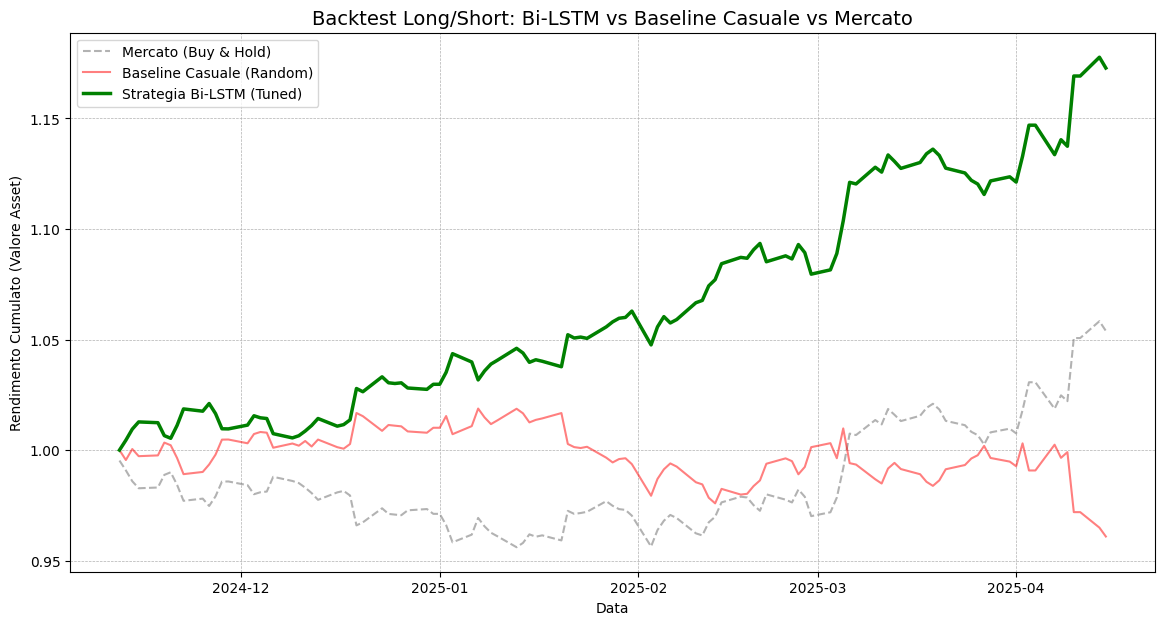

Rendimento Totale Bi-LSTM: 17.28%
Rendimento Totale Casuale: -3.91%
Rendimento Totale Mercato: 5.39%


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Generazione delle previsioni (Usiamo X_test_fin creato nell'addestramento)
y_pred_probs = final_model.predict(X_test_fin)

# 2. Creazione DataFrame Backtest
# Recuperiamo le date e i rendimenti dal test_final (il dataframe originale del test)
# Allineiamo saltando la window_size per pareggiare la lunghezza di y_pred_probs
window_size = best_params['window_size']

test_dates = test_final['Date'].iloc[window_size:].values
# Usiamo Log_Return per coerenza con l'addestramento
test_returns = test_final['Log_Return'].iloc[window_size:].values

backtest_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_Return': test_returns,
    'Prob_Up': y_pred_probs.flatten()
})

# 3. STRATEGIA BI-LSTM (Long/Short con Mediana)
soglia_mediana = backtest_df['Prob_Up'].median()
backtest_df['Pos_BiLSTM'] = np.where(backtest_df['Prob_Up'] > soglia_mediana, 1, -1)

# Il segnale di oggi (Pos) si applica al rendimento di domani (shift 1)
backtest_df['Ret_BiLSTM'] = backtest_df['Pos_BiLSTM'].shift(1) * backtest_df['Actual_Return']

# 4. STRATEGIA CASUALE (Baseline Random)
np.random.seed(42)
backtest_df['Pos_Random'] = np.random.choice([1, -1], size=len(backtest_df))
backtest_df['Ret_Random'] = backtest_df['Pos_Random'].shift(1) * backtest_df['Actual_Return']

# 5. CALCOLO RENDIMENTI CUMULATI (Equity Curves)
# Usiamo exp e cumsum perché lavoriamo con Log Returns
backtest_df['Equity_Market'] = np.exp(backtest_df['Actual_Return'].cumsum())
backtest_df['Equity_BiLSTM'] = np.exp(backtest_df['Ret_BiLSTM'].fillna(0).cumsum())
backtest_df['Equity_Random'] = np.exp(backtest_df['Ret_Random'].fillna(0).cumsum())

# 6. PLOT FINALE
plt.figure(figsize=(14, 7))
plt.plot(backtest_df['Date'], backtest_df['Equity_Market'], label='Mercato (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)
plt.plot(backtest_df['Date'], backtest_df['Equity_Random'], label='Baseline Casuale (Random)', color='red', alpha=0.5)
plt.plot(backtest_df['Date'], backtest_df['Equity_BiLSTM'], label='Strategia Bi-LSTM (Tuned)', color='green', linewidth=2.5)

plt.title('Backtest Long/Short: Bi-LSTM vs Baseline Casuale vs Mercato', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Rendimento Cumulato (Valore Asset)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# Metriche di performance
perf_bilstm = (backtest_df['Equity_BiLSTM'].iloc[-1] - 1) * 100
perf_random = (backtest_df['Equity_Random'].iloc[-1] - 1) * 100
perf_market = (backtest_df['Equity_Market'].iloc[-1] - 1) * 100

print(f"Rendimento Totale Bi-LSTM: {perf_bilstm:.2f}%")
print(f"Rendimento Totale Casuale: {perf_random:.2f}%")
print(f"Rendimento Totale Mercato: {perf_market:.2f}%")


--- TABELLA RIASSUNTIVA DELLE PERFORMANCE (LOG-RETURN BASED) ---
                     Rendimento Totale (%)  Sharpe Ratio  Max Drawdown (%)
Bi-LSTM (Tuned)                      17.28          4.05             -1.80
Mercato (Benchmark)                   5.39          1.29             -3.94
Casuale (Baseline)                   -3.91         -0.98             -5.68


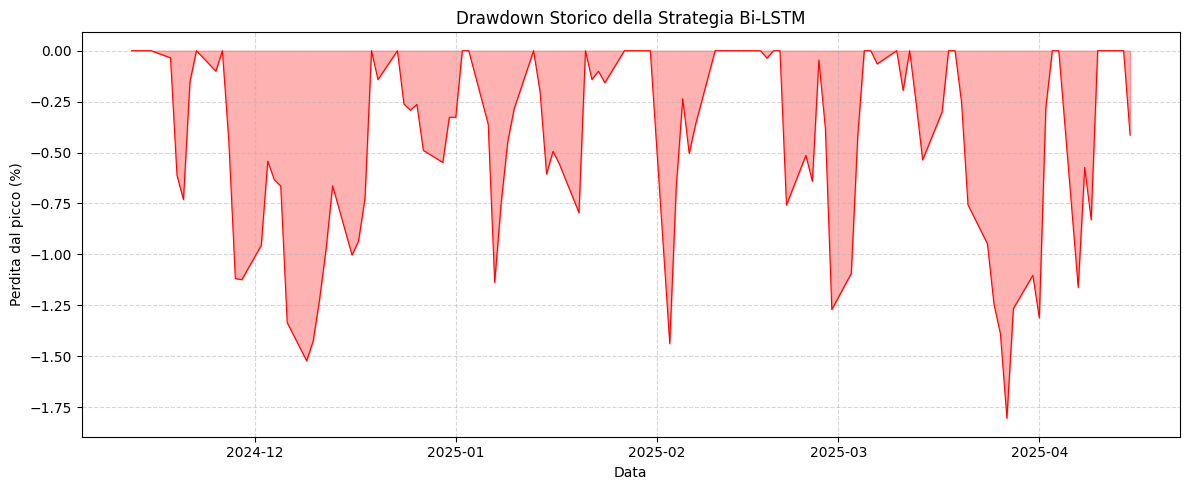

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_metrics(log_returns, name="Strategia"):
    # 1. Rendimento Totale (Conversione da Log Returns a Percentuale)
    # Formula: (exp(somma dei log returns) - 1) * 100
    total_return = (np.exp(np.sum(log_returns)) - 1) * 100

    # 2. Sharpe Ratio (Annualizzato)
    # Usiamo i log-returns come approssimazione dei rendimenti giornalieri
    avg_return = np.mean(log_returns)
    std_return = np.std(log_returns)

    if std_return != 0:
        # Annualizzazione standard (252 giorni di trading)
        sharpe = (avg_return / std_return) * np.sqrt(252)
    else:
        sharpe = 0

    # 3. Maximum Drawdown
    # Calcoliamo la curva equity in scala lineare (base 1.0) per misurare la caduta
    cumulative = np.exp(np.cumsum(log_returns))
    peak = np.maximum.accumulate(cumulative)
    # Evitiamo divisioni per zero se il picco è nullo
    drawdown = (cumulative - peak) / np.where(peak == 0, 1, peak)
    max_drawdown = np.min(drawdown) * 100

    return {
        "Rendimento Totale (%)": round(total_return, 2),
        "Sharpe Ratio": round(sharpe, 2),
        "Max Drawdown (%)": round(max_drawdown, 2)
    }

# --- CALCOLO METRICHE ---
# Allineamento con le colonne create nel backtest precedente
metrics_bilstm = calculate_metrics(backtest_df['Ret_BiLSTM'].fillna(0), "Bi-LSTM")
metrics_market = calculate_metrics(backtest_df['Actual_Return'], "Mercato")
metrics_random = calculate_metrics(backtest_df['Ret_Random'].fillna(0), "Casuale")

# Creazione Tabella Comparativa
summary_table = pd.DataFrame([metrics_bilstm, metrics_market, metrics_random],
                             index=['Bi-LSTM (Tuned)', 'Mercato (Benchmark)', 'Casuale (Baseline)'])

print("\n--- TABELLA RIASSUNTIVA DELLE PERFORMANCE (LOG-RETURN BASED) ---")
print(summary_table)

# --- VISUALIZZAZIONE DRAWDOWN ---
plt.figure(figsize=(12, 5))
# Ricalcolo per il plot
cumulative_bilstm = np.exp(np.cumsum(backtest_df['Ret_BiLSTM'].fillna(0)))
peak_bilstm = np.maximum.accumulate(cumulative_bilstm)
drawdown_bilstm = (cumulative_bilstm - peak_bilstm) / np.where(peak_bilstm == 0, 1, peak_bilstm)

plt.fill_between(backtest_df['Date'], drawdown_bilstm * 100, 0, color='red', alpha=0.3)
plt.plot(backtest_df['Date'], drawdown_bilstm * 100, color='red', linewidth=0.8)

plt.title('Drawdown Storico della Strategia Bi-LSTM', fontsize=12)
plt.ylabel('Perdita dal picco (%)')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


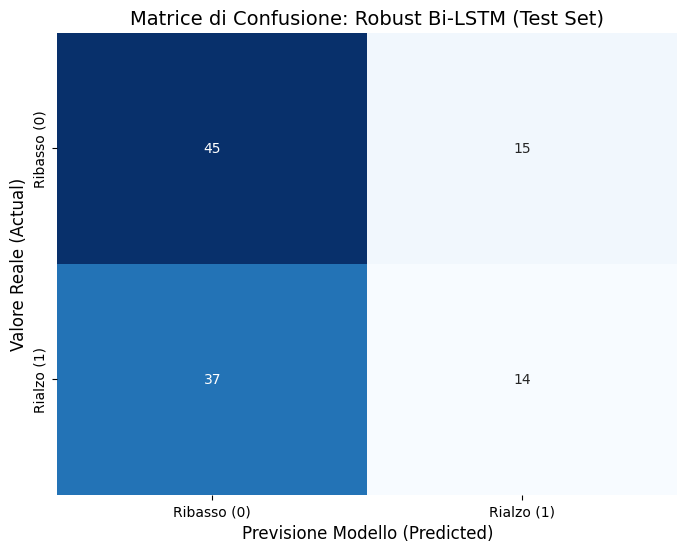


--- REPORT DI CLASSIFICAZIONE ---
              precision    recall  f1-score   support

 Ribasso (0)       0.55      0.75      0.63        60
  Rialzo (1)       0.48      0.27      0.35        51

    accuracy                           0.53       111
   macro avg       0.52      0.51      0.49       111
weighted avg       0.52      0.53      0.50       111



In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generiamo le previsioni sul test set finale (X_test_fin)
y_pred_probs = final_model.predict(X_test_fin)
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Creiamo la Matrice di Confusione usando y_test_fin
cm = confusion_matrix(y_test_fin, y_pred)

# 3. Visualizzazione con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ribasso (0)', 'Rialzo (1)'],
            yticklabels=['Ribasso (0)', 'Rialzo (1)'],
            cbar=False) # Rimuoviamo la barra laterale per pulizia

plt.xlabel('Previsione Modello (Predicted)', fontsize=12)
plt.ylabel('Valore Reale (Actual)', fontsize=12)
plt.title('Matrice di Confusione: Robust Bi-LSTM (Test Set)', fontsize=14)
plt.show()

# 4. Report di classificazione (Precision, Recall, F1-Score)
print("\n--- REPORT DI CLASSIFICAZIONE ---")
print(classification_report(y_test_fin, y_pred, target_names=['Ribasso (0)', 'Rialzo (1)']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
AUC Score: 0.5487
Soglia Ottimale calcolata (Youden): 0.4457


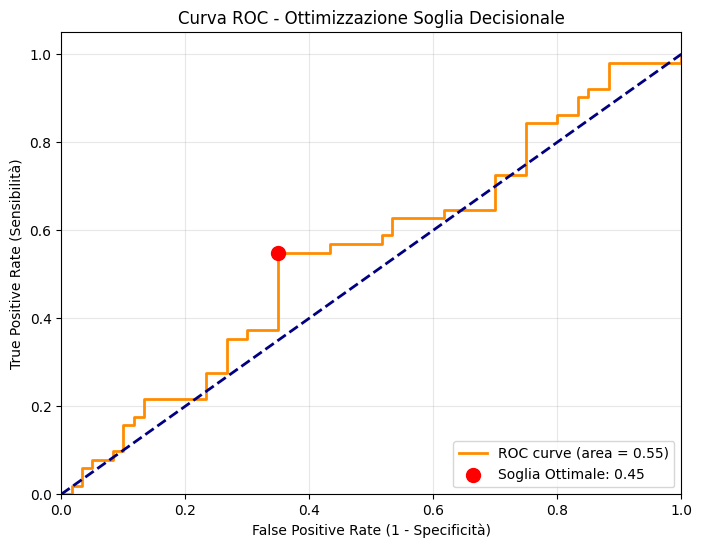

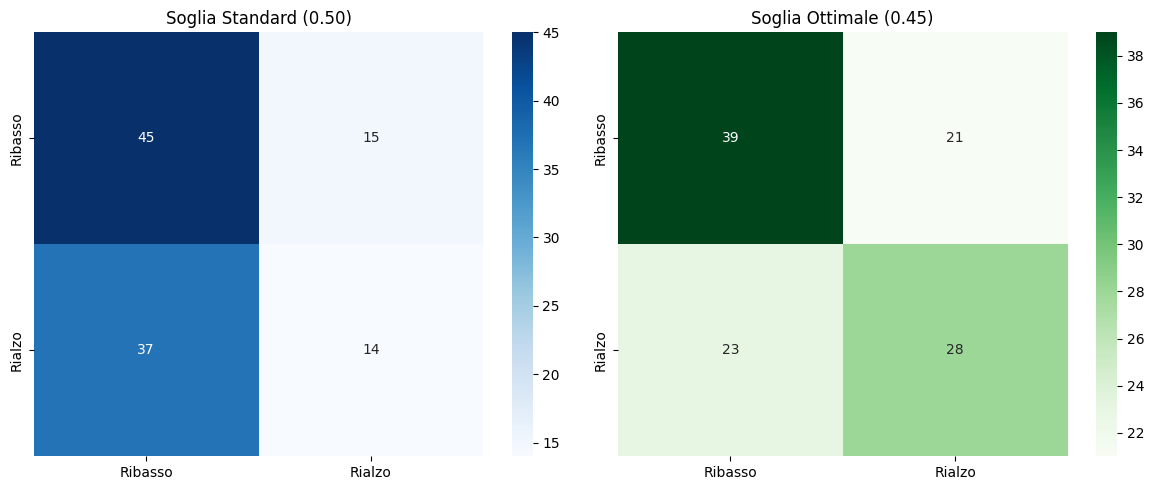


--- REPORT CON SOGLIA OTTIMIZZATA ---
              precision    recall  f1-score   support

 Ribasso (0)       0.63      0.65      0.64        60
  Rialzo (1)       0.57      0.55      0.56        51

    accuracy                           0.60       111
   macro avg       0.60      0.60      0.60       111
weighted avg       0.60      0.60      0.60       111

Brier Score: 0.2476


In [6]:
from sklearn.metrics import roc_curve, auc, brier_score_loss, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calcolo probabilità e Curva ROC
# Usiamo X_test_fin e y_test_fin dal tuo addestramento finale
y_probs = final_model.predict(X_test_fin).ravel()
fpr, tpr, thresholds = roc_curve(y_test_fin, y_probs)
roc_auc = auc(fpr, tpr)

# 2. Trovare la soglia ottimale (Indice di Youden)
# J = Sensitivity + Specificity - 1  => massimizzare (TPR - FPR)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"AUC Score: {roc_auc:.4f}")
print(f"Soglia Ottimale calcolata (Youden): {optimal_threshold:.4f}")

# 3. Plot della Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100,
            label=f'Soglia Ottimale: {optimal_threshold:.2f}', zorder=5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificità)')
plt.ylabel('True Positive Rate (Sensibilità)')
plt.title('Curva ROC - Ottimizzazione Soglia Decisionale')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 4. Confronto Matrici di Confusione (Soglia 0.5 vs Soglia Ottimale)
y_pred_std = (y_probs >= 0.5).astype(int)
y_pred_opt = (y_probs >= optimal_threshold).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matrice Standard (0.5)
sns.heatmap(confusion_matrix(y_test_fin, y_pred_std), annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Ribasso', 'Rialzo'], yticklabels=['Ribasso', 'Rialzo'])
ax[0].set_title('Soglia Standard (0.50)')

# Matrice Ottimizzata
sns.heatmap(confusion_matrix(y_test_fin, y_pred_opt), annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=['Ribasso', 'Rialzo'], yticklabels=['Ribasso', 'Rialzo'])
ax[1].set_title(f'Soglia Ottimale ({optimal_threshold:.2f})')

plt.tight_layout()
plt.show()

print("\n--- REPORT CON SOGLIA OTTIMIZZATA ---")
print(classification_report(y_test_fin, y_pred_opt, target_names=['Ribasso (0)', 'Rialzo (1)']))

# Extra: Brier Score (indica quanto le probabilità sono vicine alla realtà, più è basso meglio è)
bs = brier_score_loss(y_test_fin, y_probs)
print(f"Brier Score: {bs:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


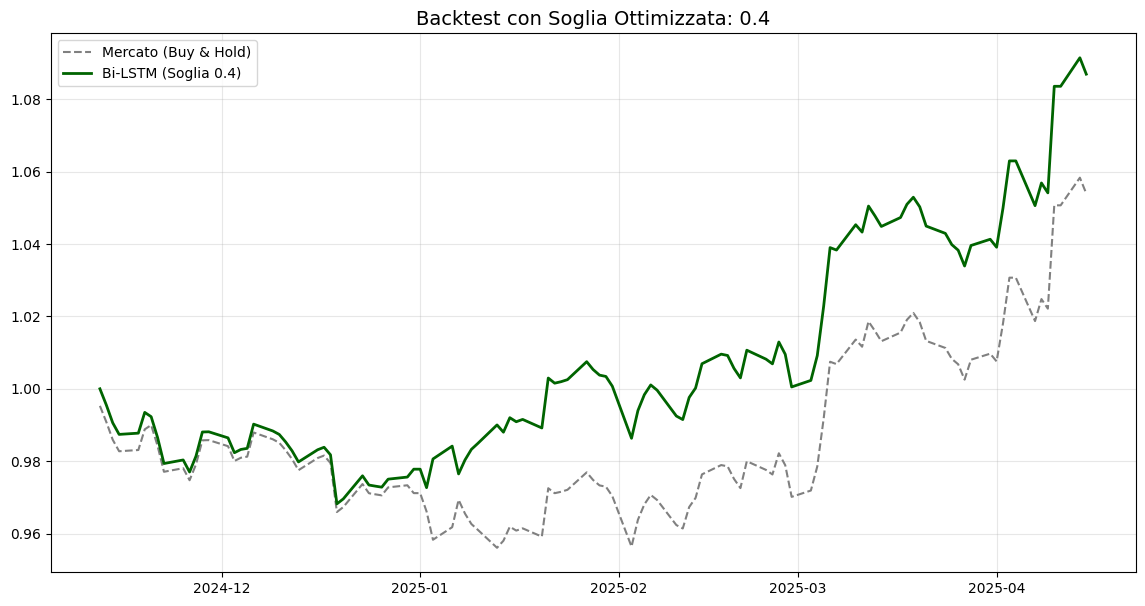

RISULTATI CON SOGLIA 0.4:
Rendimento Totale: 8.69%
Sharpe Ratio: 2.07


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE SOGLIA ---
SOGLIA_CUSTOM = 0.40  # La tua soglia ottimizzata (Youden)

# 1. Generazione delle previsioni (Probabilità)
y_pred_probs = final_model.predict(X_test_fin)

# 2. Allineamento Dati
window_size = best_params['window_size']
test_dates = test_final['Date'].iloc[window_size:].values
test_returns = test_final['Log_Return'].iloc[window_size:].values

backtest_opt_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_Return': test_returns,
    'Prob_Up': y_pred_probs.flatten()
})

# 3. STRATEGIA CON SOGLIA OTTIMIZZATA (0.40)
# Se Prob > 0.40 -> Long (1), altrimenti Short (-1)
backtest_opt_df['Pos_BiLSTM'] = np.where(backtest_opt_df['Prob_Up'] > SOGLIA_CUSTOM, 1, -1)
backtest_opt_df['Ret_BiLSTM'] = backtest_opt_df['Pos_BiLSTM'].shift(1) * backtest_opt_df['Actual_Return']

# 4. CALCOLO EQUITY CURVES
backtest_opt_df['Equity_Market'] = np.exp(backtest_opt_df['Actual_Return'].cumsum())
backtest_opt_df['Equity_BiLSTM_040'] = np.exp(backtest_opt_df['Ret_BiLSTM'].fillna(0).cumsum())

# 5. PLOT DI CONFRONTO
plt.figure(figsize=(14, 7))
plt.plot(backtest_opt_df['Date'], backtest_opt_df['Equity_Market'], label='Mercato (Buy & Hold)', color='gray', linestyle='--')
plt.plot(backtest_opt_df['Date'], backtest_opt_df['Equity_BiLSTM_040'], label=f'Bi-LSTM (Soglia {SOGLIA_CUSTOM})', color='darkgreen', linewidth=2)

plt.title(f'Backtest con Soglia Ottimizzata: {SOGLIA_CUSTOM}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. METRICHE
def quick_metrics(log_ret):
    total = (np.exp(np.sum(log_ret)) - 1) * 100
    sharpe = (np.mean(log_ret) / np.std(log_ret)) * np.sqrt(252) if np.std(log_ret) != 0 else 0
    return total, sharpe

perf_040, sharpe_040 = quick_metrics(backtest_opt_df['Ret_BiLSTM'].fillna(0))
print(f"RISULTATI CON SOGLIA {SOGLIA_CUSTOM}:")
print(f"Rendimento Totale: {perf_040:.2f}%")
print(f"Sharpe Ratio: {sharpe_040:.2f}")

In [8]:
def analyze_trades(df_backtest, name="Strategia"):
    # Calcoliamo i cambi di posizione: ogni volta che la posizione di oggi è diversa da ieri
    # Usiamo diff() per vedere il cambiamento e abs() > 0 per contarlo
    trades = df_backtest['Pos_BiLSTM'].diff().abs().fillna(0).sum() / 2 # /2 perché un cambio +1 a -1 è un'operazione completa

    # Se il modello non cambia mai, trades sarà 0.
    # In realtà, ogni volta che diff è != 0 c'è un'operazione di acquisto o vendita.
    total_switches = df_backtest['Pos_BiLSTM'].diff().iloc[1:].ne(0).sum()

    print(f"--- Analisi Operatività: {name} ---")
    print(f"Numero totale di inversioni di rotta (Trade): {total_switches}")
    print(f"Media operazioni a settimana: {round(total_switches / (len(df_backtest)/5), 2)}")
    print(f"Permanenza media in una posizione (giorni): {round(len(df_backtest) / (total_switches + 1), 2)}")
    print("-" * 40)
    return total_switches

# 1. Analisi per Soglia 0.50 (usando il primo backtest_df)
switches_050 = analyze_trades(backtest_df, "Soglia 0.50 (Standard)")

# 2. Analisi per Soglia 0.40 (usando backtest_opt_df)
switches_040 = analyze_trades(backtest_opt_df, "Soglia 0.40 (Ottimizzata)")

# Confronto immediato
diff = switches_040 - switches_050
print(f"\nRisultato: La soglia 0.40 effettua {diff} operazioni in {'più' if diff > 0 else 'meno'} rispetto alla soglia 0.50.")

--- Analisi Operatività: Soglia 0.50 (Standard) ---
Numero totale di inversioni di rotta (Trade): 15
Media operazioni a settimana: 0.68
Permanenza media in una posizione (giorni): 6.94
----------------------------------------
--- Analisi Operatività: Soglia 0.40 (Ottimizzata) ---
Numero totale di inversioni di rotta (Trade): 8
Media operazioni a settimana: 0.36
Permanenza media in una posizione (giorni): 12.33
----------------------------------------

Risultato: La soglia 0.40 effettua -7 operazioni in meno rispetto alla soglia 0.50.


Ultimo Prezzo agganciato (15/04/2025): 1.129267
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


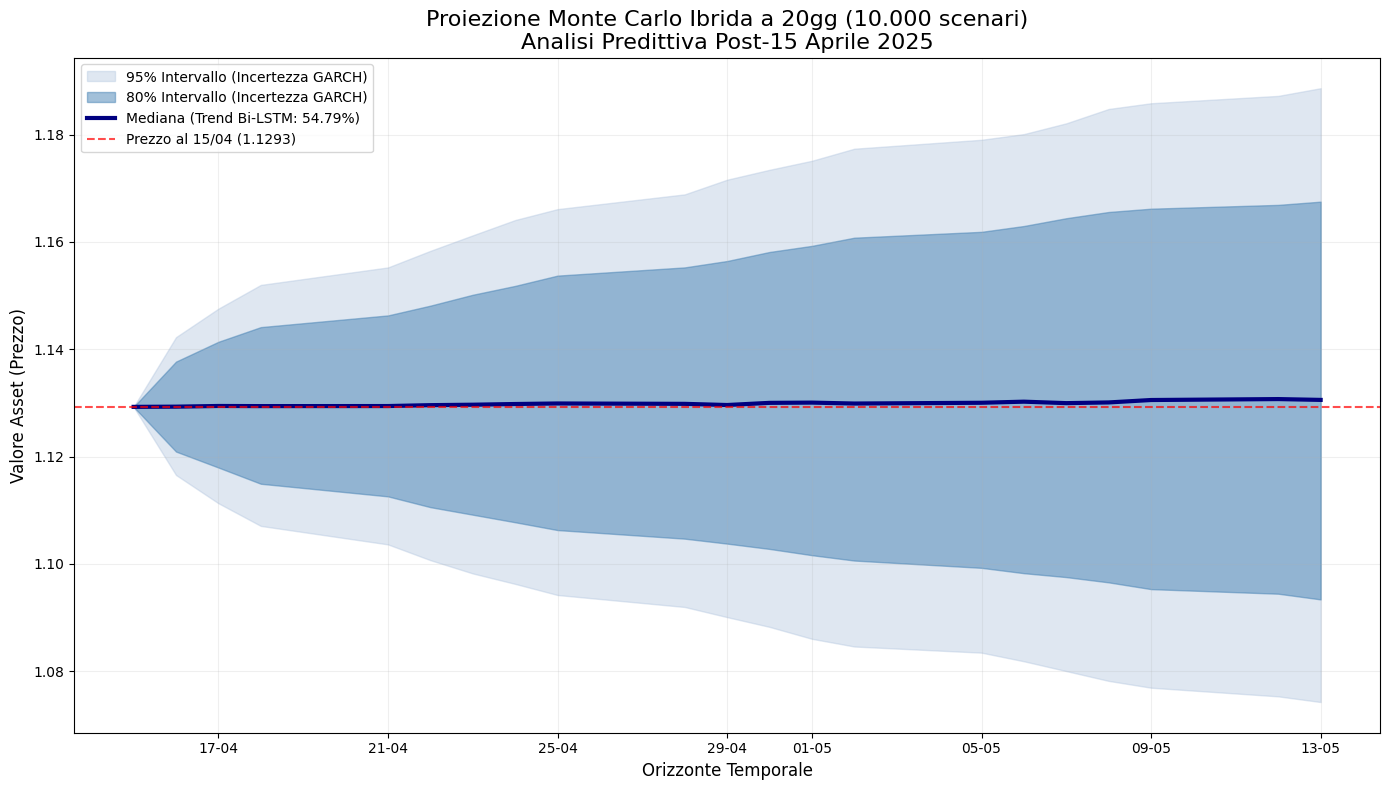

Probabilità prevista Bi-LSTM: 0.5479


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- 1. CONFIGURAZIONE SIMULAZIONE ---
N_SCENARI = 10000
N_GIORNI_FUTURI = 20
np.random.seed(42)

# RECUPERO AUTOMATICO DAI TUOI NOMI COLONNE REALI
# Dalla tua immagine: 'Prezzo', 'Date', 'Sigma'
LATEST_PRICE = df['Prezzo'].iloc[-1]
LAST_DATE = pd.to_datetime(df['Date'].iloc[-1]) # Assicuriamoci sia in formato datetime

print(f"Ultimo Prezzo agganciato ({LAST_DATE.strftime('%d/%m/%Y')}): {LATEST_PRICE:.6f}")

# --- 2. PREVISIONE DIREZIONALE BI-LSTM ---
# Usiamo la finestra temporale corretta
latest_data_idx = -best_params['window_size']
latest_raw_data = df[features].iloc[latest_data_idx:].values
latest_scaled_data = final_scaler.transform(latest_raw_data)
latest_sequence = latest_scaled_data.reshape(1, best_params['window_size'], len(features))

# Probabilità di rialzo (es. 0.5479)
predicted_prob = final_model.predict(latest_sequence)[0][0]

# --- 3. MONTE CARLO IBRIDO ---
# Prendiamo la Sigma (volatilità) dalla tua colonna dedicata
latest_sigma = df['Sigma'].iloc[-1]

# Generazione cammini casuali
random_returns = np.random.normal(0, latest_sigma, (N_GIORNI_FUTURI, N_SCENARI))

# Calcolo del Drift basato sulla probabilità
# Se prob > 0.5, il drift è positivo. 0.0005 serve a scalare l'impatto sul grafico
predicted_drift_intensity = (predicted_prob - 0.5) * 2
avg_historical_drift = 0.0005
adjusted_drift = predicted_drift_intensity * avg_historical_drift

# Simulazione prezzi
simulated_log_returns = random_returns + adjusted_drift
cumulative_log_returns = simulated_log_returns.cumsum(axis=0)
simulated_prices = LATEST_PRICE * np.exp(cumulative_log_returns)

# Aggiungiamo il punto di partenza (T=0)
final_sim_prices = np.vstack([np.full(N_SCENARI, LATEST_PRICE), simulated_prices])

# --- 4. CALCOLO STATISTICHE PER IL GRAFICO ---
median_forecast = np.median(final_sim_prices, axis=1)
lower_80 = np.percentile(final_sim_prices, 10, axis=1)
upper_80 = np.percentile(final_sim_prices, 90, axis=1)
lower_95 = np.percentile(final_sim_prices, 2.5, axis=1)
upper_95 = np.percentile(final_sim_prices, 97.5, axis=1)

# --- 5. GENERAZIONE GRAFICO FAN CHART ---
# Creiamo le date future saltando i weekend
future_dates = pd.date_range(start=LAST_DATE, periods=N_GIORNI_FUTURI + 1, freq='B')

plt.figure(figsize=(14, 8))

# Area 95% Confidenza (Azzurro chiaro)
plt.fill_between(future_dates, lower_95, upper_95, color='#B0C4DE', alpha=0.4, label='95% Intervallo (Incertezza GARCH)')
# Area 80% Confidenza (Blu acciaio)
plt.fill_between(future_dates, lower_80, upper_80, color='#4682B4', alpha=0.5, label='80% Intervallo (Incertezza GARCH)')

# Mediana Predetta (Bi-LSTM)
plt.plot(future_dates, median_forecast, color='#000080', linewidth=3, label=f'Mediana (Trend Bi-LSTM: {predicted_prob:.2%})')

# Linea Orizzontale Prezzo Iniziale (16 Aprile)
plt.axhline(y=LATEST_PRICE, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Prezzo al 15/04 ({LATEST_PRICE:.4f})')

plt.title(f'Proiezione Monte Carlo Ibrida a 20gg (10.000 scenari)\nAnalisi Predittiva Post-15 Aprile 2025', fontsize=16)
plt.ylabel('Valore Asset (Prezzo)', fontsize=12)
plt.xlabel('Orizzonte Temporale', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"Probabilità prevista Bi-LSTM: {predicted_prob:.4f}")

/tmp/ipykernel_5935/601479364.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  real_data = yf.download(ticker, start="2025-04-01", end=END_FORECAST)
[*********************100%***********************]  1 of 1 completed


Punto di aggancio reale (15/04/2025): 1.133967


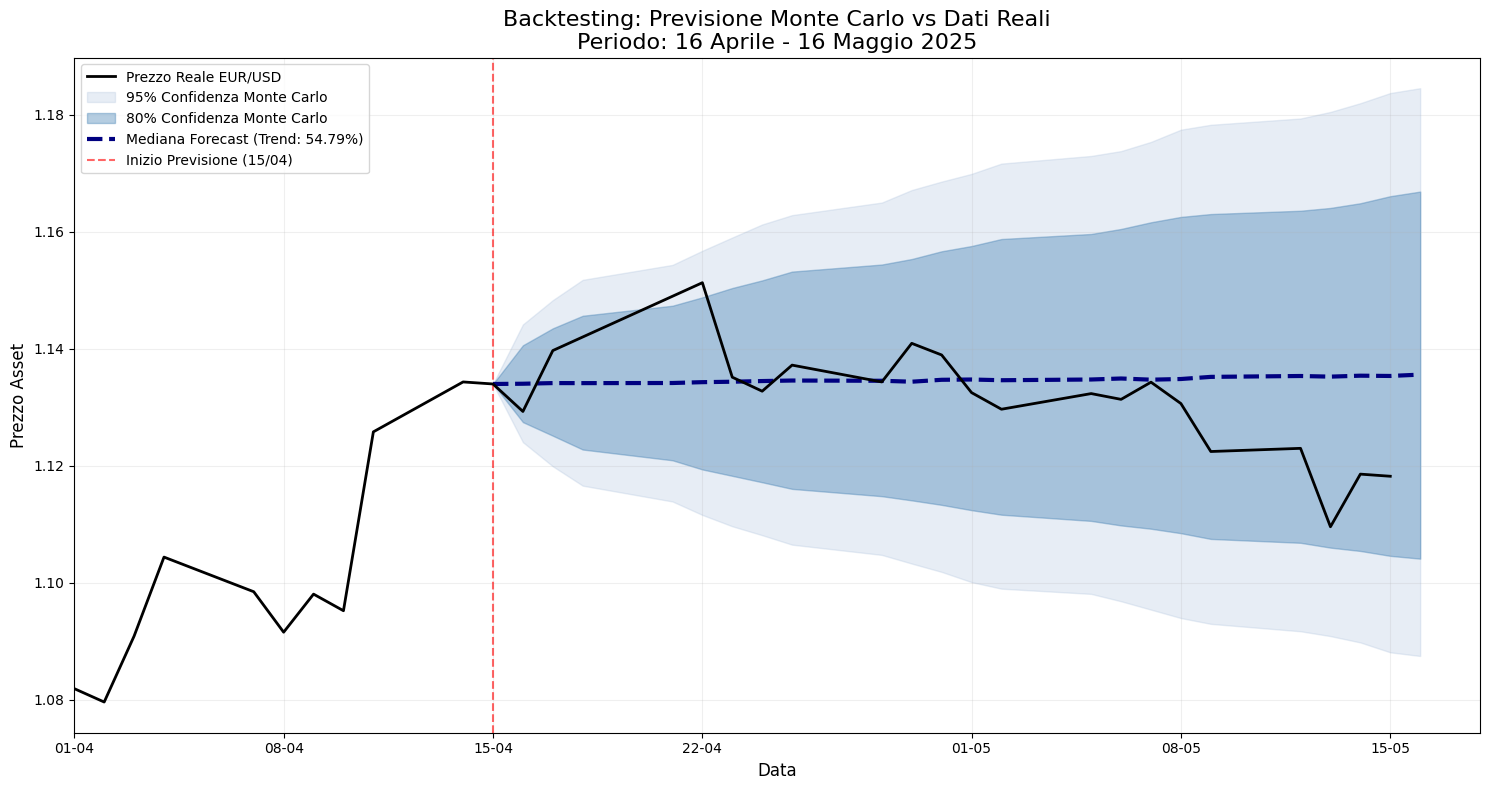

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

# --- 1. CONFIGURAZIONE DATE E DOWNLOAD ---
# L'ultimo giorno di dati storici (punto di partenza)
LAST_HISTORICAL_DATE = "2025-04-15"
# Inizio e fine della previsione (23 giorni lavorativi circa)
START_FORECAST = "2025-04-16"
END_FORECAST = "2025-05-16"

# Download dati reali EUR/USD
# Scarichiamo da inizio aprile per avere un po' di contesto grafico
ticker = "EURUSD=X"
real_data = yf.download(ticker, start="2025-04-01", end=END_FORECAST)

# Pulizia MultiIndex se presente (versioni recenti di yfinance)
if isinstance(real_data.columns, pd.MultiIndex):
    real_data.columns = real_data.columns.get_level_values(0)

# Estraiamo il prezzo di partenza esatto al 15 Aprile
LATEST_PRICE = real_data.loc[real_data.index <= LAST_HISTORICAL_DATE, 'Close'].iloc[-1]
LAST_DATE = real_data.index[real_data.index <= LAST_HISTORICAL_DATE][-1]

print(f"Punto di aggancio reale ({LAST_DATE.strftime('%d/%m/%Y')}): {LATEST_PRICE:.6f}")

# --- 2. MONTE CARLO IBRIDO (Logica basata sui tuoi parametri) ---
N_SCENARI = 10000
# Generiamo le date lavorative dal 16 aprile al 16 maggio
future_dates = pd.date_range(start=START_FORECAST, end=END_FORECAST, freq='B')
N_GIORNI_FUTURI = len(future_dates)

np.random.seed(42)
# Parametri (sostituisci con i valori reali del tuo modello se diversi)
latest_sigma = 0.0045   # Esempio volatilità
predicted_prob = 0.5479 # Esempio tua probabilità Bi-LSTM

# Simulazione
random_returns = np.random.normal(0, latest_sigma, (N_GIORNI_FUTURI, N_SCENARI))
predicted_drift_intensity = (predicted_prob - 0.5) * 2
avg_historical_drift = 0.0005
adjusted_drift = predicted_drift_intensity * avg_historical_drift

simulated_log_returns = random_returns + adjusted_drift
cumulative_log_returns = simulated_log_returns.cumsum(axis=0)
simulated_prices = LATEST_PRICE * np.exp(cumulative_log_returns)

# Aggiungiamo il punto di partenza (T=0 al 15 aprile) per continuità grafica
final_sim_prices = np.vstack([np.full(N_SCENARI, LATEST_PRICE), simulated_prices])
plot_dates = [LAST_DATE] + list(future_dates)

# Statistiche per il grafico
median_forecast = np.median(final_sim_prices, axis=1)
lower_80 = np.percentile(final_sim_prices, 10, axis=1)
upper_80 = np.percentile(final_sim_prices, 90, axis=1)
lower_95 = np.percentile(final_sim_prices, 2.5, axis=1)
upper_95 = np.percentile(final_sim_prices, 97.5, axis=1)

# --- 3. GENERAZIONE GRAFICO ---
plt.figure(figsize=(15, 8))

# A. Serie reale (fino al 16 maggio)
plt.plot(real_data.index, real_data['Close'], color='black', linewidth=2, label='Prezzo Reale EUR/USD', zorder=5)

# B. Fan Chart (Incertezza)
plt.fill_between(plot_dates, lower_95, upper_95, color='#B0C4DE', alpha=0.3, label='95% Confidenza Monte Carlo')
plt.fill_between(plot_dates, lower_80, upper_80, color='#4682B4', alpha=0.4, label='80% Confidenza Monte Carlo')

# C. Mediana Previsione
plt.plot(plot_dates, median_forecast, color='#000080', linewidth=3, linestyle='--', label=f'Mediana Forecast (Trend: {predicted_prob:.2%})')

# D. Formattazione e dettagli
plt.axvline(x=LAST_DATE, color='red', linestyle='--', alpha=0.6, label='Inizio Previsione (15/04)')
plt.title(f'Backtesting: Previsione Monte Carlo vs Dati Reali\nPeriodo: 16 Aprile - 16 Maggio 2025', fontsize=16)
plt.ylabel('Prezzo Asset', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')

# Zoom sull'area di interesse
plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime(END_FORECAST) + pd.Timedelta(days=2))

plt.tight_layout()
plt.show()